# HBV hydrological model forced with DestinE historical forcing data
In this notebook we generate forcing data for the HBV hydrological model from the DestinE Climate DT CMIP6 historical simulation, using the ICON model (1990–~2020).

Unlike the SSP3-7.0 future data (step_1c) which is available directly as zarr on Cache B, the historical simulation is not yet available as a zarr store. It is accessed via the **polytope API** using `earthkit.data`. The data is returned in GRIB format on a HEALPix grid and is regridded to a regular lat/lon grid before being clipped to the catchment shape.

Authentication uses the same DESP credentials as step_1c. Make sure `DESP_USERNAME` and `DESP_PASSWORD` are set in your `.env` file.

For detailed descriptions of the forcing generation steps, see [step_1a](step_1a_generate_historical_forcing.ipynb).

In [1]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import json
import sys
import geopandas as gpd
import rioxarray

# Niceties
from rich import print

# This will work normally for HPC
try:
    from scripts.forcing_destine import DestinEHistoricalForcing
    from scripts.dest_auth import authenticate as dest_auth
except ImportError:
    # Add the project root to Python path for use on SRC
    project_root = Path().resolve().parent
    sys.path.append(str(project_root))

    from scripts.forcing_destine import DestinEHistoricalForcing
    from scripts.dest_auth import authenticate as dest_auth

# dest_auth()

import earthkit.data
import earthkit.regrid
from dask.diagnostics import ProgressBar
from datetime import datetime

In [2]:
# General eWaterCycle
import ewatercycle
import ewatercycle.forcing

In [3]:
%%capture cap
try:
    %run desp-authentication.py
except:
    %run ../scripts/desp-authentication.py

In [4]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

In [5]:
# Parameters, these get changed when running on HPC
country = "australia"
region_id = "camelsaus_102101A"
settings_path = "settings.json"

In [6]:
# Load settings
with open(settings_path, "r") as json_file:
    settings = json.load(json_file)

In [7]:
display(settings)

{'caravan_id': 'camelsaus_102101A',
 'country': 'australia',
 'calibration_start_date': '1994-08-01T00:00:00Z',
 'calibration_end_date': '2004-07-31T00:00:00Z',
 'validation_start_date': '2004-08-01T00:00:00Z',
 'validation_end_date': '2014-07-31T00:00:00Z',
 'future_start_date': '2029-08-01T00:00:00Z',
 'future_end_date': '2039-08-31T00:00:00Z',
 'CMIP_info': {'dataset': ['MPI-ESM1-2-LR'],
  'ensembles': ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'],
  'experiments': ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585'],
  'project': 'CMIP6',
  'grid': 'gn'},
 'base_path': '/home/mmelotto/ewatercycleClimateImpact/HBV',
 'path_caravan': '/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/caravan',
 'path_ERA5': '/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/ERA5',
 'path_DestinE': '/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/DestinE',
 'path_DestinE_historical': '/home/mmelotto/ewa

## DestinE CMIP6 historical forcing

The DestinE Climate DT provides a CMIP6 historical simulation using the ICON model at ~40 km resolution (HEALPix H128 grid, referred to as "standard" resolution). The historical run covers 1990 to ~2020, overlapping with both the calibration (1994–2004) and validation (2004–2014) periods used in this workflow.

Data is retrieved via the **polytope API**, a request-based interface to the DestinE data portal. The request specifies the CMIP6 historical activity, the ICON model, and the surface variables needed: 2 m temperature (`t2m`), total precipitation (`tp`), and surface solar radiation downwards (`ssrd`).

Because the data arrives on a HEALPix grid (a pixelised sphere, not a regular lat/lon grid), it is first regridded to a 0.5° regular grid using `earthkit.regrid` before being clipped to the catchment shapefile.

> **Note:** If `generate` is slow, this is expected — the polytope API retrieves multi-year GRIB data and the regridding adds processing time. The result is cached to disk so subsequent calls use `load`.

In [8]:
%%time 

# Generate forcing for the calibration + validation period
try:
    DestinE_hist_forcing_object = DestinEHistoricalForcing.load(settings["path_DestinE_historical"])
    print("Loading")
except FileNotFoundError:
# DestinE_hist_forcing_object = DestinEHistoricalForcing.generate(
    print("Generating")
    DestinE_hist_forcing_object = DestinEHistoricalForcing.generate(
        start_time=settings["calibration_start_date"],
        end_time=settings["validation_end_date"],
        # end_time=end_date,
        directory=settings["path_DestinE_historical"],
        shape=settings["path_shape"],
    )

display(DestinE_hist_forcing_object)

Loading

LumpedMakkinkForcing(start_time='1994-08-01T00:00:00Z', end_time='2014-07-31T00:00:00Z', directory=PosixPath('/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/DestinE_historical'), shape=PosixPath('/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/caravan/camelsaus_102101A.shp'), filenames={'pr': '/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/DestinE_historical/DestinE_historic_day_pr_1994_08_01-2014_07_31.nc', 'tas': '/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/DestinE_historical/DestinE_historic_day_tas_1994_08_01-2014_07_31.nc', 'rsds': '/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/DestinE_historical/DestinE_historic_day_rsds_1994_08_01-2014_07_31.nc', 'evspsblpot': '/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/DestinE_historical/DestinE_historic_day_evsps

CPU times: user 5.91 ms, sys: 214 μs, total: 6.12 ms
Wall time: 6.82 ms


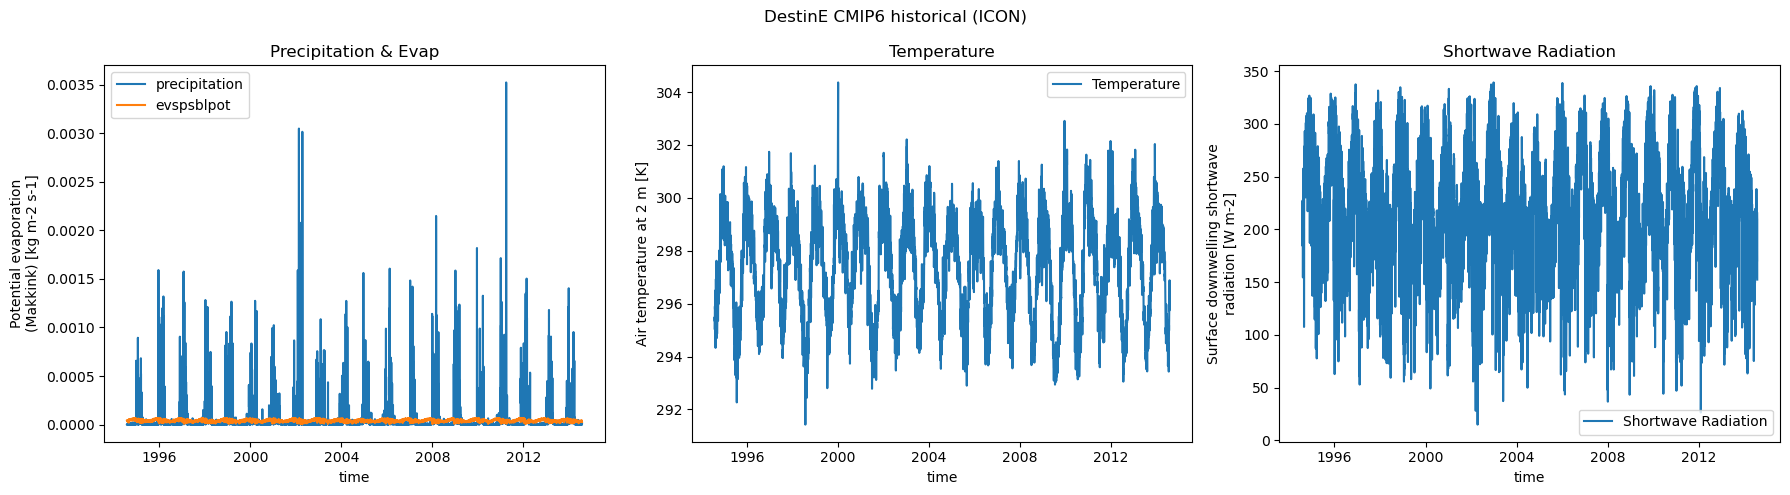

In [9]:

ds_DestinE_hist = xr.open_mfdataset([
    DestinE_hist_forcing_object["pr"],
    DestinE_hist_forcing_object["tas"],
    DestinE_hist_forcing_object["rsds"],
    DestinE_hist_forcing_object["evspsblpot"],
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: precipitation + evspsblpot
ds_DestinE_hist["pr"].plot(ax=axes[0], label="precipitation")
ds_DestinE_hist["evspsblpot"].plot(ax=axes[0], label="evspsblpot")
axes[0].set_title("Precipitation & Evap")
axes[0].legend()

# Subplot 2: temperature
ds_DestinE_hist["tas"].plot(ax=axes[1], label="Temperature")
axes[1].set_title("Temperature")
axes[1].legend()

# Subplot 3: radiation
ds_DestinE_hist["rsds"].plot(ax=axes[2], label="Shortwave Radiation")
axes[2].set_title("Shortwave Radiation")
axes[2].legend()

plt.suptitle("DestinE CMIP6 historical (ICON)")
plt.tight_layout()
plt.show()